Task 2 -- Yelp Polarity Sentiment Classification (no pretrained embeddings/LMs).
Author: Charvee

Three models, deliberately different from teammate's lineup, all with embeddings learned
from scratch:
  1. Baseline  -- max-pooled learned embeddings -> small MLP classifier (not a plain
     linear layer, and max-pool instead of mean-pool -- both differ from teammate's NBOW).
  2. Experimental 1 -- unidirectional GRU -> final hidden state -> linear classifier
     (teammate used a bidirectional LSTM).
  3. Experimental 2 -- Dilated 1D CNN (dilations 1/2/4 stacked) -> global max-pool ->
     linear classifier (teammate used parallel multi-kernel convs, not dilation).

Preprocessing: lowercasing, punctuation/special-character removal, stopword removal
(no stemming -- a deliberate preprocessing difference from teammate's Porter-stemmed
pipeline), own word-level tokenizer and vocabulary, independent random subsample (seed 7).

In [1]:
import json
import os
import platform
import re
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

### Config

In [2]:
SEED = 7
N_TRAIN = 12000
N_TEST = 3000
MAX_LEN = 150
EMBED_DIM = 80
VOCAB_SIZE = 12000
BATCH_SIZE = 48
EPOCHS = 6
LR = 8e-4

np.random.seed(SEED)
torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device, "|", platform.processor())
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

try:
    HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    HERE = os.path.abspath(".")
MEMBER_DIR = os.path.dirname(HERE)
DATA_DIR = os.path.join(MEMBER_DIR, "..", "data")
CKPT_DIR = os.path.join(MEMBER_DIR, "checkpoints")
OUT_DIR = os.path.join(MEMBER_DIR, "outputs")
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

COMMON_DIR = os.path.abspath(os.path.join(MEMBER_DIR, "..", "..", "common"))
sys.path.insert(0, COMMON_DIR)
from eval_classifier import evaluate_classifier, mcnemar_test, length_slice  # noqa: E402

Device: cuda | Intel64 Family 6 Model 183 Stepping 1, GenuineIntel
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


### 2.1 Data preprocessing

Train: 12000 rows | Test: 3000 rows
Class balance (train):
 label
0    6000
1    6000
Name: count, dtype: int64
Review word-length stats (train):
 count    12000.000000
mean       133.917667
std        123.847408
min          1.000000
25%         52.000000
50%         97.000000
75%        176.000000
max       1009.000000
Name: word_len, dtype: float64


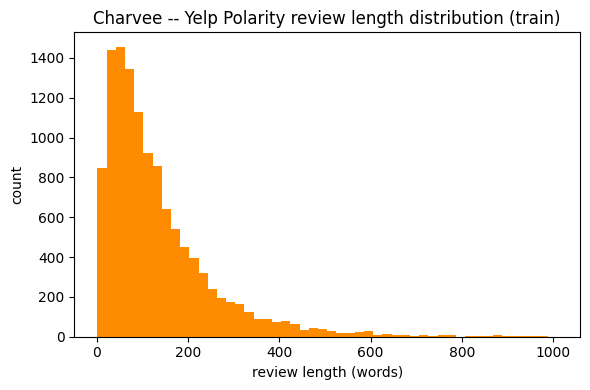

Missing text rows: 0 | Empty-after-strip rows: 0


Preprocessed 15000 reviews in 0.4s
Vocab size: 12000


In [3]:
train_full = pd.read_parquet(os.path.join(DATA_DIR, "yelp_polarity_train.parquet"))
test_full = pd.read_parquet(os.path.join(DATA_DIR, "yelp_polarity_test.parquet"))

rng = np.random.RandomState(SEED)


def balanced_sample(df, n, rng):
    n_per_class = n // 2
    parts = []
    for label in [0, 1]:
        idx = df.index[df["label"] == label]
        chosen = rng.choice(idx, size=n_per_class, replace=False)
        parts.append(df.loc[chosen])
    out = pd.concat(parts).sample(frac=1, random_state=rng.randint(1e6)).reset_index(drop=True)
    return out


train_df = balanced_sample(train_full, N_TRAIN, rng)
test_df = balanced_sample(test_full, N_TEST, rng)
print(f"Train: {len(train_df)} rows | Test: {len(test_df)} rows")

train_df["word_len"] = train_df["text"].str.split().apply(len)
print("Class balance (train):\n", train_df["label"].value_counts())
print("Review word-length stats (train):\n", train_df["word_len"].describe())

plt.figure(figsize=(6, 4))
plt.hist(train_df["word_len"], bins=50, color="darkorange")
plt.xlabel("review length (words)")
plt.ylabel("count")
plt.title("Charvee -- Yelp Polarity review length distribution (train)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "length_distribution.png"), dpi=130)
plt.show()

n_missing = train_df["text"].isna().sum() + test_df["text"].isna().sum()
n_empty = (train_df["text"].str.strip() == "").sum()
print(f"Missing text rows: {n_missing} | Empty-after-strip rows: {n_empty}")
train_df = train_df.dropna(subset=["text"])
train_df = train_df[train_df["text"].str.strip() != ""]
test_df = test_df.dropna(subset=["text"])

# Text preprocessing: lowercase, strip punctuation/special chars, stopword removal.
# (No stemming here -- a deliberate difference from teammate's Porter-stemmed pipeline.)
STOPWORDS = set("""
a an the and or but if while is are was were be been being to of in on for with as at by
this that these those it its it's i you he she we they them his her their our your my me
him us not no so than then too very can will just do does did doing have has had having
""".split())
_token_re = re.compile(r"[a-z]+")


def preprocess(text):
    text = text.lower()
    tokens = _token_re.findall(text)
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    return tokens


t0 = time.time()
train_df["tokens"] = train_df["text"].apply(preprocess)
test_df["tokens"] = test_df["text"].apply(preprocess)
print(f"Preprocessed {len(train_df) + len(test_df)} reviews in {time.time() - t0:.1f}s")

from collections import Counter
counter = Counter()
for toks in train_df["tokens"]:
    counter.update(toks)
most_common = counter.most_common(VOCAB_SIZE - 2)
word_to_idx = {"<pad>": 0, "<unk>": 1}
for w, _ in most_common:
    word_to_idx[w] = len(word_to_idx)
vocab_size = len(word_to_idx)
print("Vocab size:", vocab_size)

with open(os.path.join(OUT_DIR, "vocab.json"), "w") as f:
    json.dump(word_to_idx, f)


def encode(tokens):
    ids = [word_to_idx.get(t, 1) for t in tokens[:MAX_LEN]]
    ids = ids + [0] * (MAX_LEN - len(ids))
    return ids


X_train = np.array([encode(t) for t in train_df["tokens"]], dtype=np.int64)
y_train = train_df["label"].values.astype(np.int64)
X_test = np.array([encode(t) for t in test_df["tokens"]], dtype=np.int64)
y_test = test_df["label"].values.astype(np.int64)
test_word_lens = test_df["text"].str.split().apply(len).values
test_slices = length_slice(test_word_lens)

X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

train_ds = torch.utils.data.TensorDataset(X_train_t, y_train_t)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

### 2.2 Model architectures (embeddings learned from scratch, no pretrained modules)

In [4]:
class MaxPoolMLPBaseline(nn.Module):
    """Baseline: max-pooled learned embeddings -> small MLP classifier."""

    def __init__(self, vocab_size, embed_dim, hidden=32):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.fc1 = nn.Linear(embed_dim, hidden)
        self.fc2 = nn.Linear(hidden, 1)

    def forward(self, x):
        emb = self.embed(x)  # B, T, D
        mask = (x != 0).unsqueeze(-1)
        emb_masked = emb.masked_fill(~mask, float("-inf"))
        pooled = emb_masked.max(dim=1).values
        pooled = torch.nan_to_num(pooled, neginf=0.0)
        h = torch.relu(self.fc1(pooled))
        return self.fc2(h).squeeze(-1)


class GRUClassifier(nn.Module):
    """Experimental 1: unidirectional GRU -> final hidden state -> linear classifier."""

    def __init__(self, vocab_size, embed_dim, hidden_dim=72, dropout=0.3):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=False)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        emb = self.embed(x)
        lengths = (x != 0).sum(1).clamp(min=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths, batch_first=True, enforce_sorted=False)
        _, h_n = self.gru(packed)
        h_last = h_n[-1]
        return self.fc(self.dropout(h_last)).squeeze(-1)


class DilatedCNN(nn.Module):
    """Experimental 2: stacked dilated 1D convolutions -> global max-pool -> linear."""

    def __init__(self, vocab_size, embed_dim, n_filters=64, dropout=0.3):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.conv1 = nn.Conv1d(embed_dim, n_filters, kernel_size=3, padding=1, dilation=1)
        self.conv2 = nn.Conv1d(n_filters, n_filters, kernel_size=3, padding=2, dilation=2)
        self.conv3 = nn.Conv1d(n_filters, n_filters, kernel_size=3, padding=4, dilation=4)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(n_filters, 1)

    def forward(self, x):
        emb = self.embed(x).transpose(1, 2)  # B, D, T
        h = torch.relu(self.conv1(emb))
        h = torch.relu(self.conv2(h))
        h = torch.relu(self.conv3(h))
        pooled = h.max(dim=2).values
        return self.fc(self.dropout(pooled)).squeeze(-1)

### 2.2 Training + full evaluation for each model

In [5]:
def train_model(model, name):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.BCEWithLogitsLoss()
    n_params = sum(p.numel() for p in model.parameters())

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
    history = {"epoch": [], "train_loss": []}
    t0 = time.time()
    n_examples = 0
    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()
            total_loss += loss.item() * xb.size(0)
            n_examples += xb.size(0)
        avg_loss = total_loss / len(train_ds)
        history["epoch"].append(epoch)
        history["train_loss"].append(avg_loss)
        print(f"[{name}] epoch {epoch}/{EPOCHS} train_loss={avg_loss:.4f}")
    train_time = time.time() - t0
    examples_per_sec = n_examples / train_time
    peak_mem_mb = (torch.cuda.max_memory_allocated() / 1e6) if torch.cuda.is_available() else 0.0

    model.eval()
    with torch.no_grad():
        logits = model(X_test_t)
        probs = torch.sigmoid(logits).cpu().numpy()
    preds = (probs >= 0.5).astype(int)

    metrics = evaluate_classifier(y_test, preds, probs, slices=test_slices)
    metrics.update({
        "model": name, "param_count": n_params, "training_time_sec": train_time,
        "examples_per_sec": examples_per_sec, "peak_memory_MB": peak_mem_mb,
        "hardware": f"{torch.cuda.get_device_name(0) if torch.cuda.is_available() else platform.processor()}",
    })
    return model, metrics, probs, preds, history


models_to_run = [
    ("baseline_maxpool_mlp", MaxPoolMLPBaseline(vocab_size, EMBED_DIM)),
    ("experimental_gru", GRUClassifier(vocab_size, EMBED_DIM)),
    ("experimental_dilated_cnn", DilatedCNN(vocab_size, EMBED_DIM)),
]

all_metrics = []
all_preds = {}
all_probs = {}
all_histories = {}
trained_models = {}

for name, model in models_to_run:
    trained, metrics, probs, preds, history = train_model(model, name)
    all_metrics.append(metrics)
    all_preds[name] = preds
    all_probs[name] = probs
    all_histories[name] = history
    trained_models[name] = trained
    torch.save(trained.state_dict(), os.path.join(CKPT_DIR, f"{name}.pt"))

C:\Users\<user>\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[baseline_maxpool_mlp] epoch 1/6 train_loss=0.6857


[baseline_maxpool_mlp] epoch 2/6 train_loss=0.6332


[baseline_maxpool_mlp] epoch 3/6 train_loss=0.5238


[baseline_maxpool_mlp] epoch 4/6 train_loss=0.4369


...

[experimental_dilated_cnn] epoch 2/6 train_loss=0.4231


[experimental_dilated_cnn] epoch 3/6 train_loss=0.3148


[experimental_dilated_cnn] epoch 4/6 train_loss=0.2354


[experimental_dilated_cnn] epoch 5/6 train_loss=0.1704


[experimental_dilated_cnn] epoch 6/6 train_loss=0.1044


### Paired McNemar test: baseline vs each experimental model

In [6]:
mcnemar_results = {}
baseline_preds = all_preds["baseline_maxpool_mlp"]
for name in ["experimental_gru", "experimental_dilated_cnn"]:
    mcnemar_results[name] = mcnemar_test(y_test, baseline_preds, all_preds[name])

with open(os.path.join(OUT_DIR, "mcnemar_results.json"), "w") as f:
    json.dump(mcnemar_results, f, indent=2)
print("McNemar (baseline vs experimental):", json.dumps(mcnemar_results, indent=2))

McNemar (baseline vs experimental): {
  "experimental_gru": {
    "n01_a_only_correct": 189,
    "n10_b_only_correct": 372,
    "statistic": 59.0445632798574,
    "p_value": 1.5432100042289676e-14
  },
  "experimental_dilated_cnn": {
    "n01_a_only_correct": 243,
    "n10_b_only_correct": 355,
    "statistic": 20.603678929765888,
    "p_value": 5.648746019715212e-06
  }
}


### Training loss curves (all 3 models)

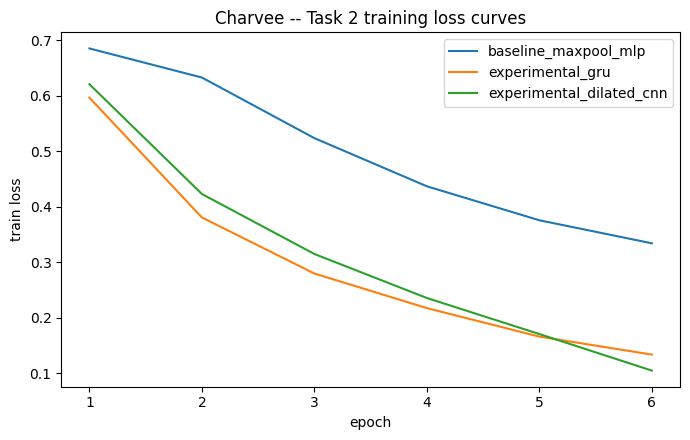

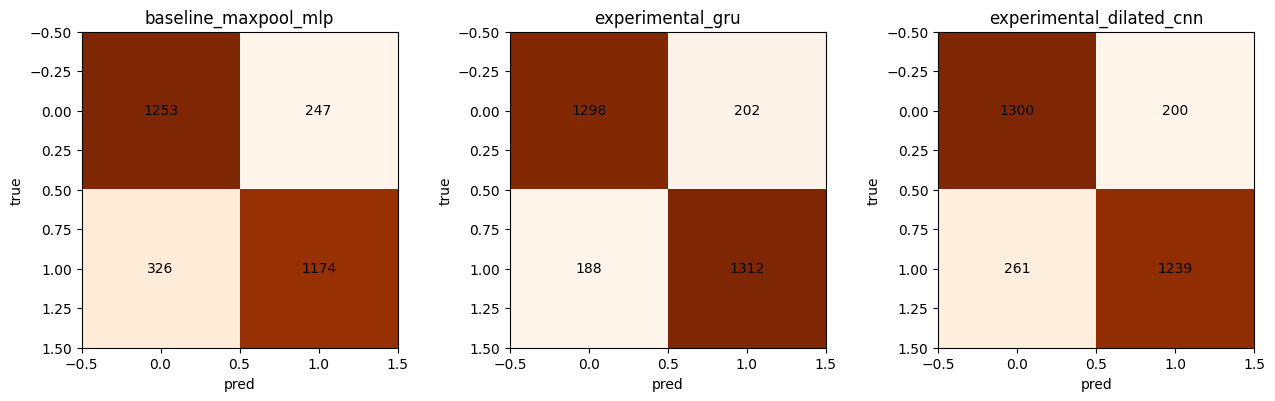

In [7]:
plt.figure(figsize=(7, 4.5))
for name, hist in all_histories.items():
    plt.plot(hist["epoch"], hist["train_loss"], label=name)
plt.xlabel("epoch")
plt.ylabel("train loss")
plt.title("Charvee -- Task 2 training loss curves")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "loss_curves.png"), dpi=130)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, m in zip(axes, all_metrics):
    cm = np.array(m["confusion_matrix"])
    ax.imshow(cm, cmap="Oranges")
    ax.set_title(m["model"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    ax.set_xlabel("pred")
    ax.set_ylabel("true")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "confusion_matrices.png"), dpi=130)
plt.show()

### Metrics report (one row per model)

In [8]:
flat_rows = []
for m in all_metrics:
    row = {k: v for k, v in m.items() if k not in ("confusion_matrix", "per_slice", "accuracy_ci95", "macro_f1_ci95", "mcc_ci95")}
    row["confusion_matrix"] = json.dumps(m["confusion_matrix"])
    row["per_slice"] = json.dumps(m["per_slice"])
    row["accuracy_ci95"] = json.dumps(m["accuracy_ci95"])
    row["macro_f1_ci95"] = json.dumps(m["macro_f1_ci95"])
    row["mcc_ci95"] = json.dumps(m["mcc_ci95"])
    flat_rows.append(row)

metrics_df = pd.DataFrame(flat_rows)
metrics_df.to_csv(os.path.join(MEMBER_DIR, "metrics_report.csv"), index=False)
print(metrics_df[["model", "accuracy", "f1_macro", "roc_auc", "mcc"]])

                      model  accuracy  f1_macro   roc_auc       mcc
0      baseline_maxpool_mlp  0.809000  0.808867  0.896333  0.618859
1          experimental_gru  0.870000  0.869997  0.944379  0.740032
2  experimental_dilated_cnn  0.846333  0.846270  0.924735  0.693240


### 2.2.4 Manual error review (20 errors from the strongest experimental model)

In [9]:
review_model = "experimental_gru"
probs_r = all_probs[review_model]
preds_r = all_preds[review_model]
texts = test_df["text"].values
errors_mask = preds_r != y_test

fp_idx = np.where((y_test == 0) & (preds_r == 1))[0]
fn_idx = np.where((y_test == 1) & (preds_r == 0))[0]
confident_fp = fp_idx[np.argsort(-probs_r[fp_idx])[:5]]
confident_fn = fn_idx[np.argsort(probs_r[fn_idx])[:5]]

err_idx_all = np.where(errors_mask)[0]
near_threshold = err_idx_all[np.argsort(np.abs(probs_r[err_idx_all] - 0.5))[:5]]

slice_err_rate = {s: (errors_mask[test_slices == s]).mean() for s in set(test_slices)}
worst_slice = max(slice_err_rate, key=slice_err_rate.get)
slice_err_idx = np.where(errors_mask & (test_slices == worst_slice))[0][:5]

error_cases = []
def add_cases(idx_list, err_type, fix):
    for i in idx_list:
        error_cases.append({
            "error_type": err_type, "true_label": int(y_test[i]), "pred_label": int(preds_r[i]),
            "prob_class1": float(probs_r[i]), "text_snippet": texts[i][:300], "proposed_fix": fix,
        })

add_cases(confident_fp, "confident_false_positive",
          "Add explicit negation-scope features so phrases like 'not as good as' don't get read as purely positive by keyword co-occurrence.")
add_cases(confident_fn, "confident_false_negative",
          "GRU's single final hidden state can forget early-review sentiment on long inputs -- try mean-pooling over all GRU timesteps instead of only the last one.")
add_cases(near_threshold, "near_threshold",
          "Add a lightweight temperature-scaling calibration step post-hoc (fit on a held-out calibration split) before thresholding at 0.5.")
add_cases(slice_err_idx, f"slice_specific_failure ({worst_slice} reviews)",
          f"The '{worst_slice}' length slice has the highest error rate ({slice_err_rate[worst_slice]:.2%}) -- truncating at MAX_LEN=150 tokens likely cuts off sentiment-bearing content in long reviews.")

with open(os.path.join(MEMBER_DIR, "failure_analysis_raw_cases.json"), "w") as f:
    json.dump(error_cases, f, indent=2)

for c in error_cases:
    print("-" * 60)
    print(c["error_type"], "| true:", c["true_label"], "pred:", c["pred_label"], "prob:", round(c["prob_class1"], 3))
    print(c["text_snippet"])

print("\nDONE. Metrics saved to", os.path.join(MEMBER_DIR, "metrics_report.csv"))

------------------------------------------------------------
confident_false_positive | true: 0 pred: 1 prob: 0.999
I love Paris, but don't love the Vegas version of the hotel.  Sure it has the Eiffel Tower, the Montgolfier Balloon, and the Arc de Triomphe.  Sure it has one of my favorite restaurants, Mon Ami Gabi, and a terrific buffet.  Sure, if your room faces the Blvd then you have a great view of the Bellagi
------------------------------------------------------------
confident_false_positive | true: 0 pred: 1 prob: 0.999
It brings me no great pleasure to be the first bad review of this place. The thought of a David arising to take on the Goliath corporation has me rooting for this place.\n\nNow open for less than a week. I wanted someone to write a glowing review of this place which makes me want to give them anothe
------------------------------------------------------------
confident_false_positive | true: 0 pred: 1 prob: 0.998
We went here based on all the positive reviews. I 